# 2026 World Cup: Matchup Probability Analysis

Two-part analysis: **(A) Group stage** (72 guaranteed matchups, determines who advances) and **(B) Knockout stage** (probabilistic matchups, 100,000 bracket simulations).


## 1. Setup

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style='whitegrid', font_scale=1.05)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

results = pd.read_csv('../data/2026_monte_carlo_results.csv', index_col=0)
matchup_matrix = pd.read_csv('../data/2026_matchup_probabilities.csv', index_col=0)
matchup_list = pd.read_csv('../data/2026_matchup_list.csv')
elo_data = pd.read_csv('../data/elo_current_2026.csv').set_index('Team')['Elo_Current']
fixtures = pd.read_csv('../data/2026_group_stage.csv')

print(f'Simulations: 100,000')
print(f'Matchup matrix: {matchup_matrix.shape[0]} x {matchup_matrix.shape[1]} teams')
print(f'Knockout matchups (prob > 0.1%): {len(matchup_list)}')
print(f'Elo range: {elo_data.min():.0f} - {elo_data.max():.0f}')

Simulations: 100,000
Matchup matrix: 48 x 48 teams
Knockout matchups (prob > 0.1%): 1024
Elo range: 1552 - 2216


---

# PART A: GROUP STAGE

All 72 group matches are guaranteed. These results determine who advances to the knockout stage.


## A1. Group Stage Fixtures by Group

In [2]:
# Full group stage fixture list
for grp in sorted(fixtures['Group'].unique()):
    grp_fix = fixtures[fixtures['Group'] == grp].sort_values('Date')
    teams_in_grp = sorted(set(grp_fix['Home_Team'].unique()) | set(grp_fix['Away_Team'].unique()))
    elos = [f'{elo_data.get(t,0):.0f}' for t in teams_in_grp]
    
    print(f'GROUP {grp}: {" | ".join(f"{t} ({e})" for t, e in zip(teams_in_grp, elos))}')
    for _, r in grp_fix.iterrows():
        he = elo_data.get(r['Home_Team'], 0)
        ae = elo_data.get(r['Away_Team'], 0)
        fav = r['Home_Team'] if he > ae else r['Away_Team']
        print(f'  {r["Date"][:10]}  {r["Home_Team"]:<22} vs {r["Away_Team"]:<22}  (fav: {fav})')
    print()

GROUP A: Czech Republic (1837) | Mexico (1957) | South Africa (1673) | South Korea (1895)
  2026-06-11  Mexico                 vs South Africa            (fav: Mexico)
  2026-06-11  South Korea            vs Czech Republic          (fav: South Korea)
  2026-06-18  Czech Republic         vs South Africa            (fav: Czech Republic)
  2026-06-18  Mexico                 vs South Korea             (fav: Mexico)
  2026-06-24  Czech Republic         vs Mexico                  (fav: Mexico)
  2026-06-24  South Africa           vs South Korea             (fav: South Korea)

GROUP B: Bosnia and Herzegovina (1653) | Canada (1903) | Qatar (1552) | Switzerland (1990)
  2026-06-12  Canada                 vs Bosnia and Herzegovina  (fav: Canada)
  2026-06-13  Qatar                  vs Switzerland             (fav: Switzerland)
  2026-06-18  Switzerland            vs Bosnia and Herzegovina  (fav: Switzerland)
  2026-06-18  Canada                 vs Qatar                   (fav: Canada)
  2026-06-

## A2. Group Stage Qualification Rates

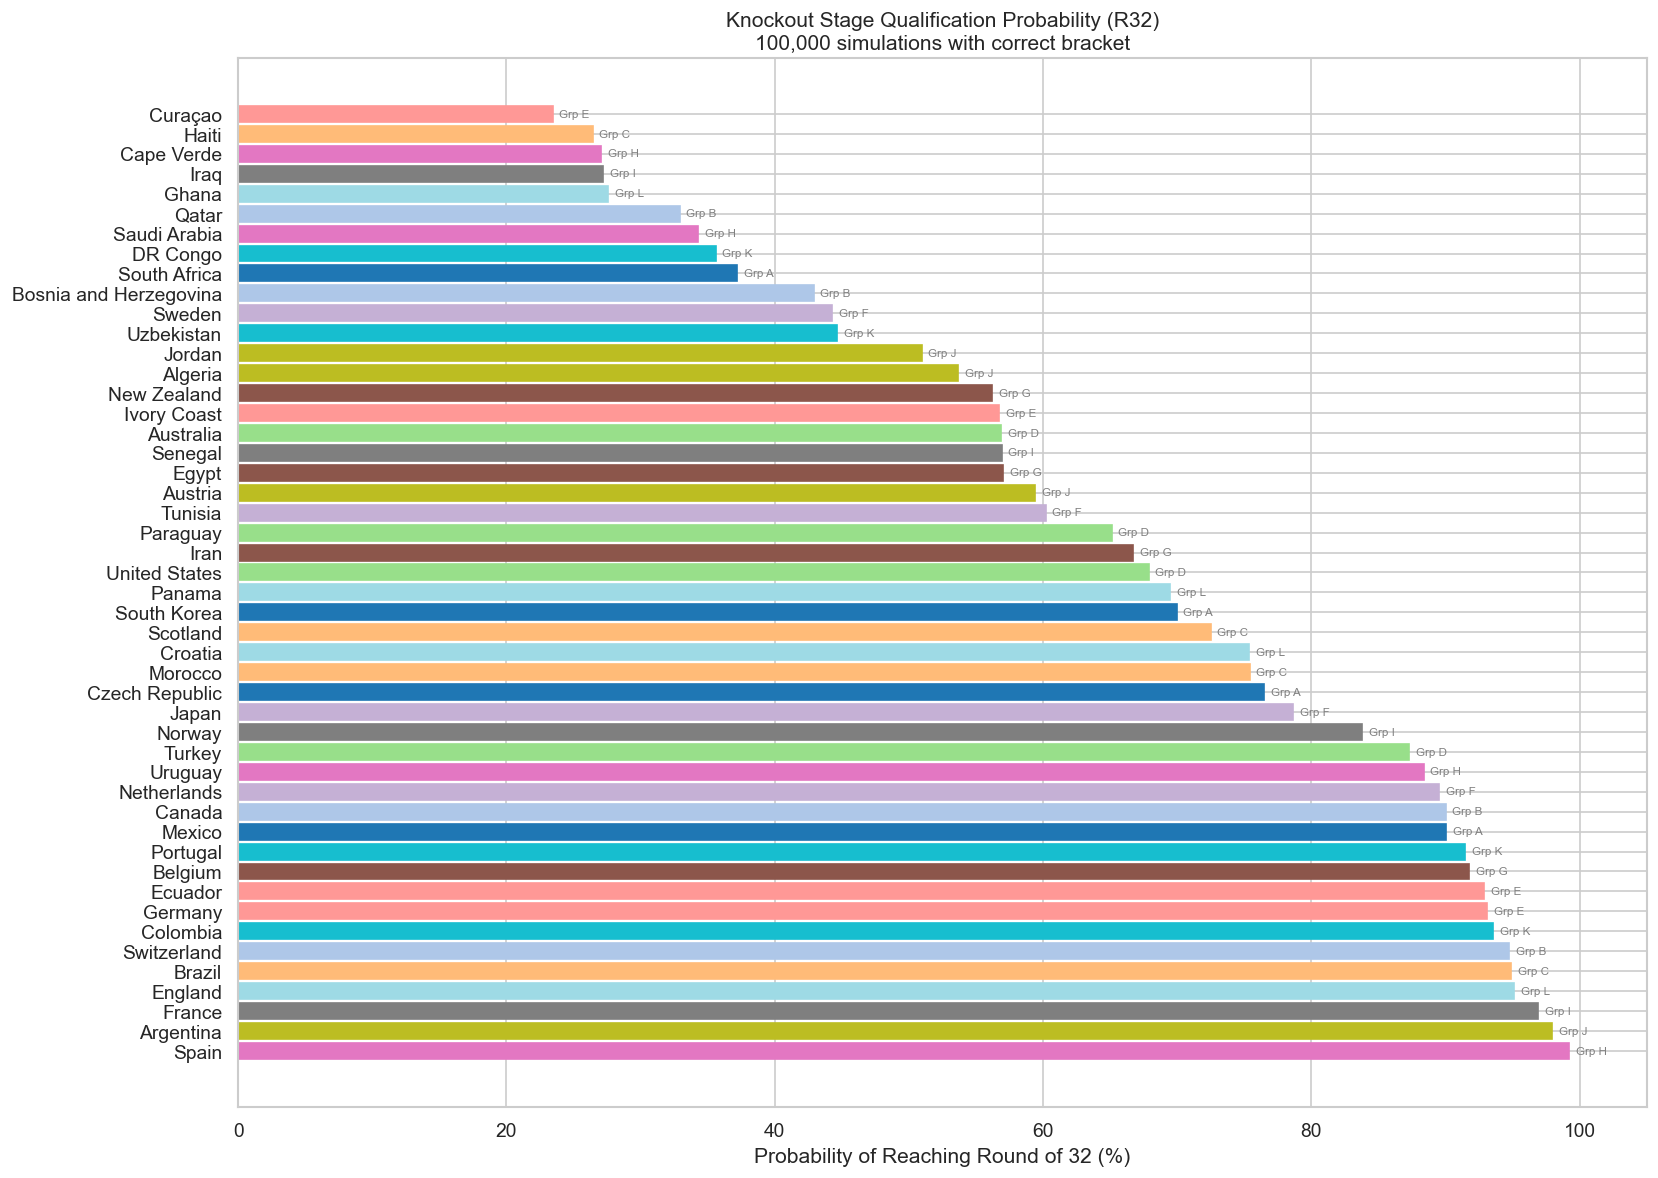

In [3]:
# From Monte Carlo: how often each team advances from their group
qual = results[['R32_Prob', 'R16_Prob', 'QF_Prob', 'SF_Prob', 'Final_Prob', 'Winner_Prob']].copy()
qual = qual.sort_values('R32_Prob', ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(qual.index, qual['R32_Prob'] * 100, color='steelblue', edgecolor='white')

# Color by group
group_colors = plt.cm.tab20(np.linspace(0, 1, 12))
team_to_group = {}
for _, row in fixtures.iterrows():
    team_to_group[row['Home_Team']] = row['Group']
    team_to_group[row['Away_Team']] = row['Group']

for bar, team in zip(bars, qual.index):
    grp = team_to_group.get(team, '?')
    grp_idx = ord(grp) - ord('A') if grp != '?' else 0
    bar.set_color(group_colors[grp_idx % 12])
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'Grp {grp}', va='center', fontsize=7, color='gray')

ax.set_title('Knockout Stage Qualification Probability (R32)\n100,000 simulations with correct bracket')
ax.set_xlabel('Probability of Reaching Round of 32 (%)')
ax.set_xlim(0, 105)
plt.tight_layout()

---

# PART B: KNOCKOUT STAGE

Probabilistic matchups based on correct 2026 bracket structure. 100,000 simulations tracking every pairwise encounter in R32 through Final.


## B1. Top Knockout Matchup Probabilities

In [4]:
top = matchup_list.nlargest(40, 'Probability')
print(f'TOP 40 MOST LIKELY KNOCKOUT MATCHUPS')
print('=' * 70)
for i, (_, r) in enumerate(top.iterrows()):
    ea = elo_data.get(r['Team_A'], 0)
    eb = elo_data.get(r['Team_B'], 0)
    fav = r['Team_A'] if ea > eb else r['Team_B']
    marker = ' ← BRACKET LOCK' if r['Probability'] > 0.3 else ''
    print(f'{i+1:2}. {r["Team_A"]:<22} vs {r["Team_B"]:<22}  {r["Probability"]*100:5.1f}%  (Elo: {ea:.0f} vs {eb:.0f}){marker}')

TOP 40 MOST LIKELY KNOCKOUT MATCHUPS
 1. Argentina              vs Uruguay                  43.5%  (Elo: 2190 vs 1986) ← BRACKET LOCK
 2. Argentina              vs Spain                    32.9%  (Elo: 2190 vs 2216) ← BRACKET LOCK
 3. Ecuador                vs France                   30.0%  (Elo: 2033 vs 2160) ← BRACKET LOCK
 4. Brazil                 vs Netherlands              29.5%  (Elo: 2081 vs 2006)
 5. France                 vs Germany                  29.0%  (Elo: 2160 vs 2032)
 6. Brazil                 vs Japan                    26.5%  (Elo: 2081 vs 2008)
 7. Austria                vs Spain                    24.6%  (Elo: 1929 vs 2216)
 8. Germany                vs Norway                   23.2%  (Elo: 2032 vs 1994)
 9. Algeria                vs Spain                    22.9%  (Elo: 1885 vs 2216)
10. Portugal               vs Spain                    22.7%  (Elo: 2049 vs 2216)
11. Netherlands            vs Scotland                 22.2%  (Elo: 2006 vs 1857)
12. Belgium     

## B2. Matchup Probability Heatmap (Knockout Only)

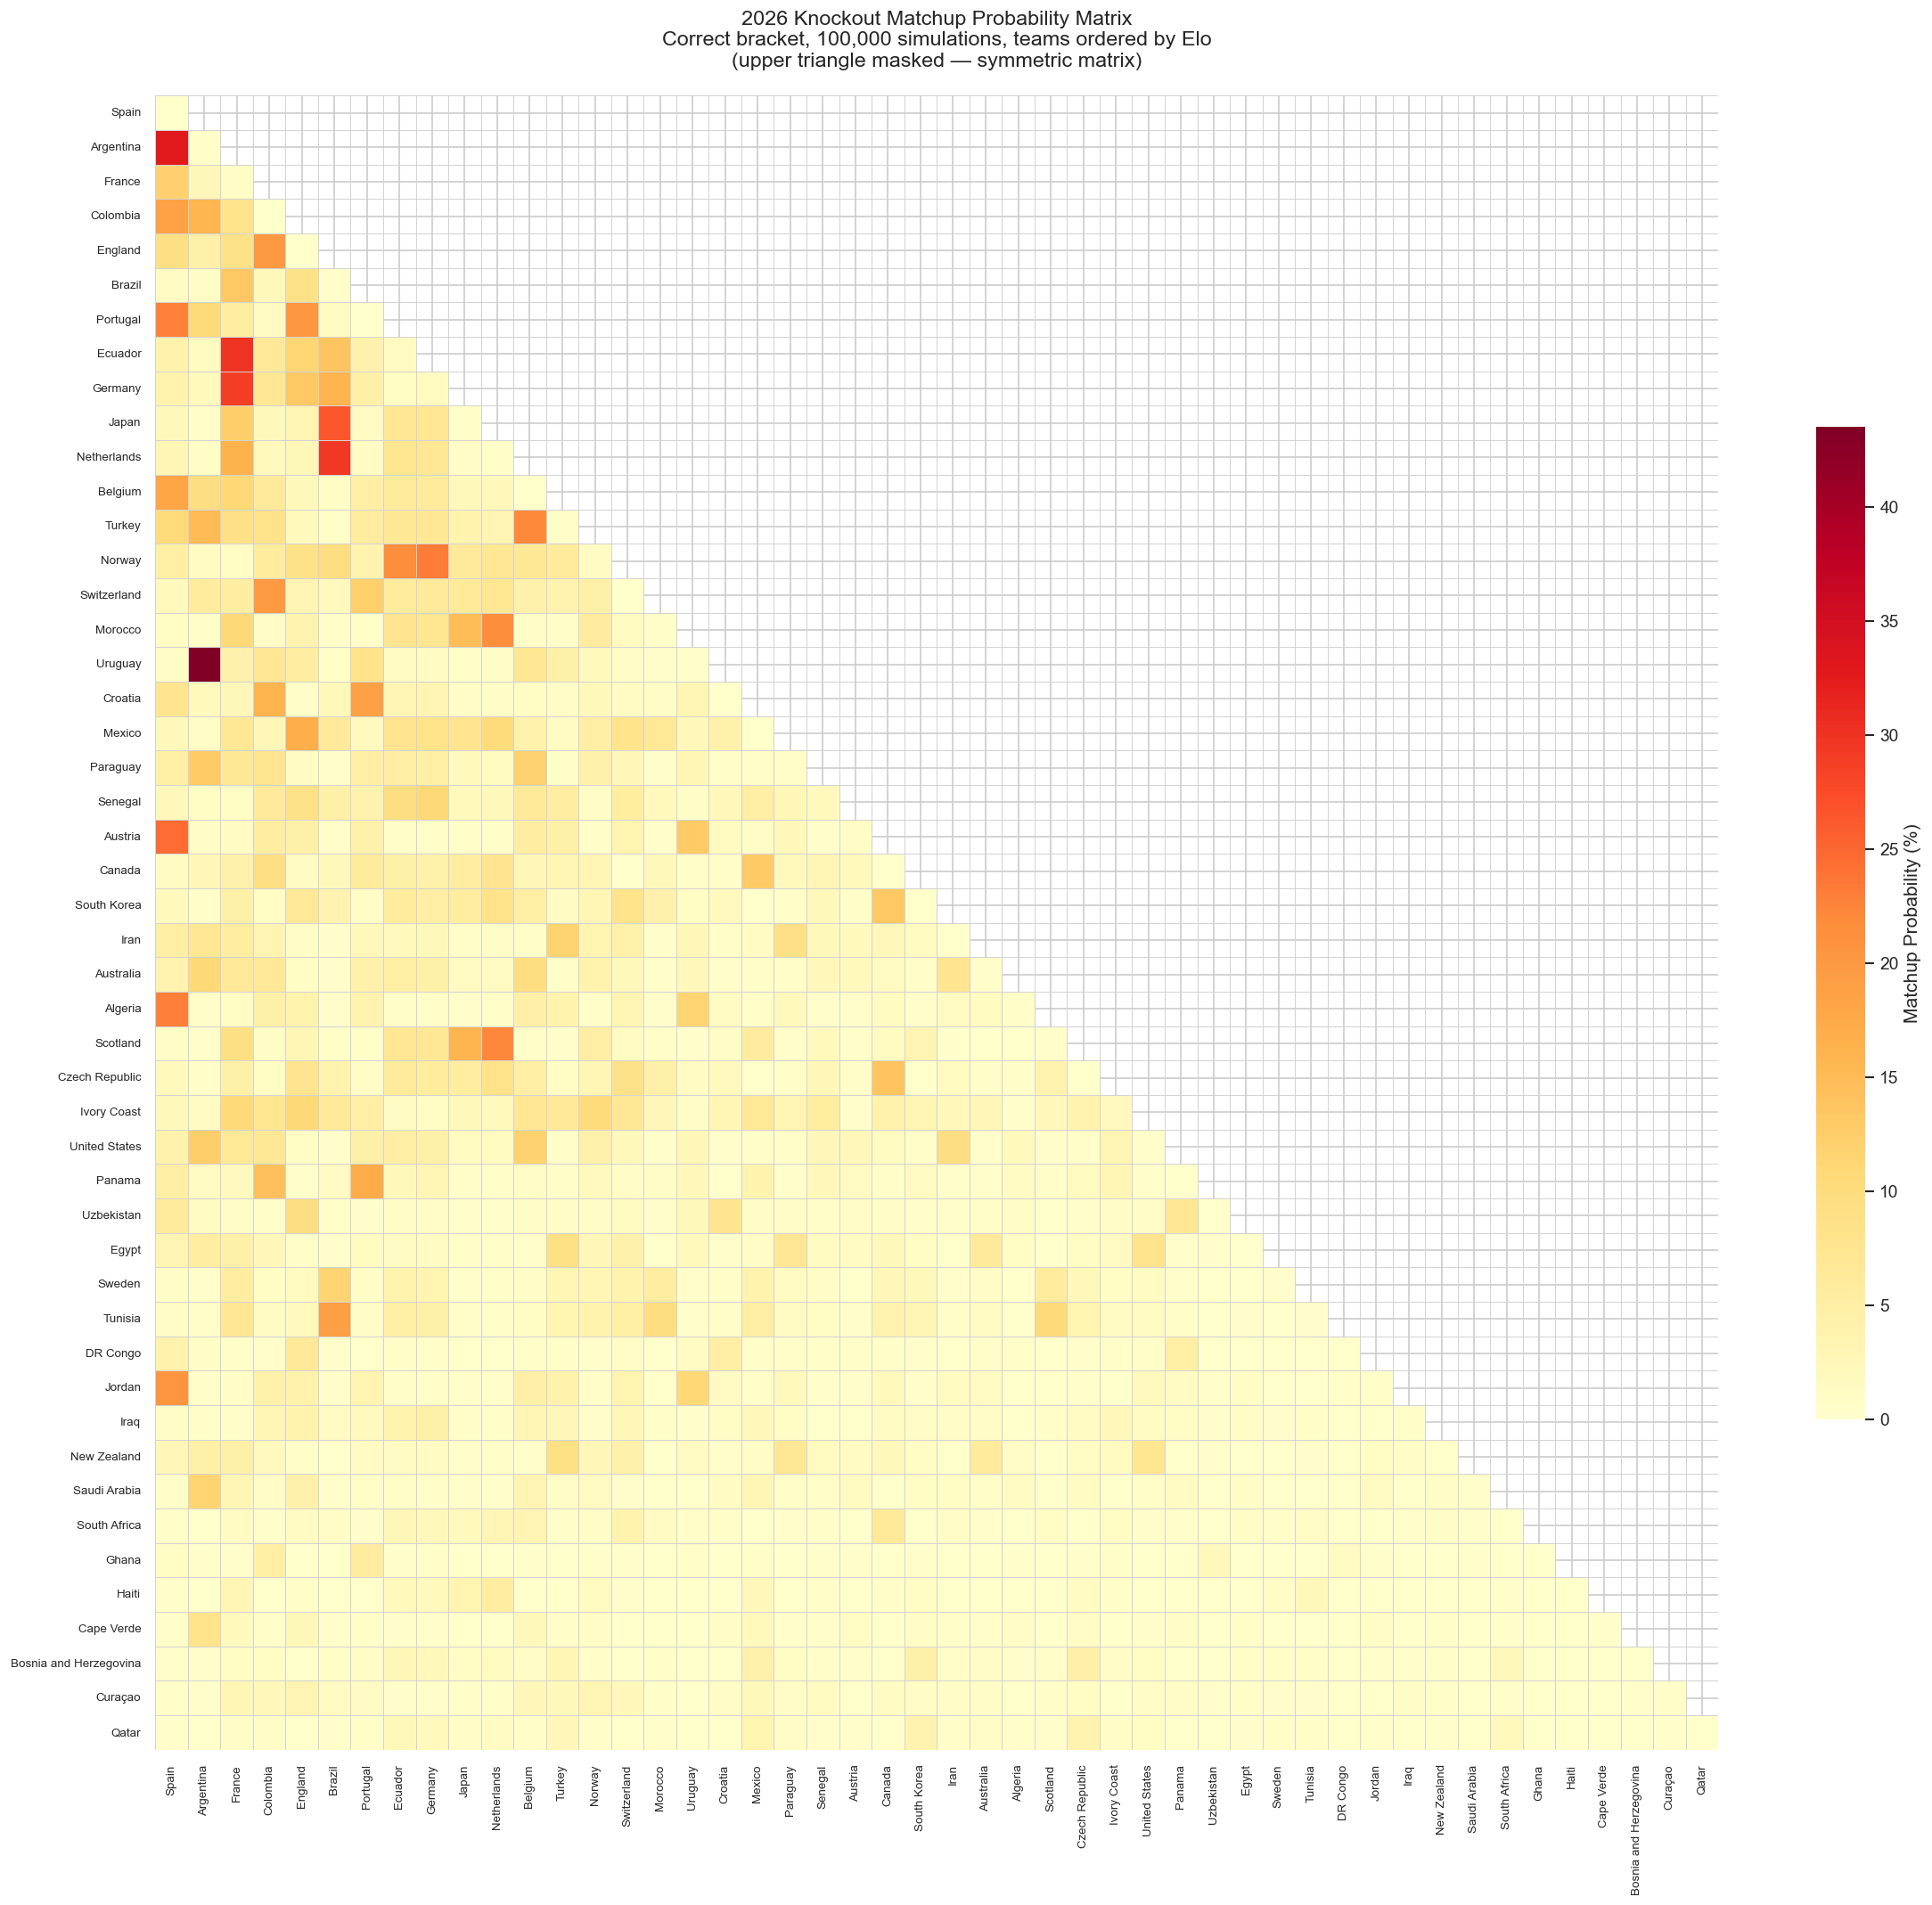

In [5]:
# Order teams by Elo
team_order = elo_data.sort_values(ascending=False).index.tolist()
mat = matchup_matrix.loc[team_order, team_order] * 100

fig, ax = plt.subplots(figsize=(20, 18))
mask = np.triu(np.ones_like(mat, dtype=bool), k=1)

sns.heatmap(mat, mask=mask, ax=ax, cmap='YlOrRd',
            vmin=0, vmax=mat.values.max(),
            cbar_kws={'label': 'Matchup Probability (%)', 'shrink': 0.6},
            linewidths=0.5, linecolor='lightgray',
            xticklabels=True, yticklabels=True, annot=False)

ax.set_title('2026 Knockout Matchup Probability Matrix\n'
             'Correct bracket, 100,000 simulations, teams ordered by Elo\n'
             '(upper triangle masked — symmetric matrix)',
             fontsize=14, pad=20)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()

## B3. Annotated Heatmap (Top 24 Teams)

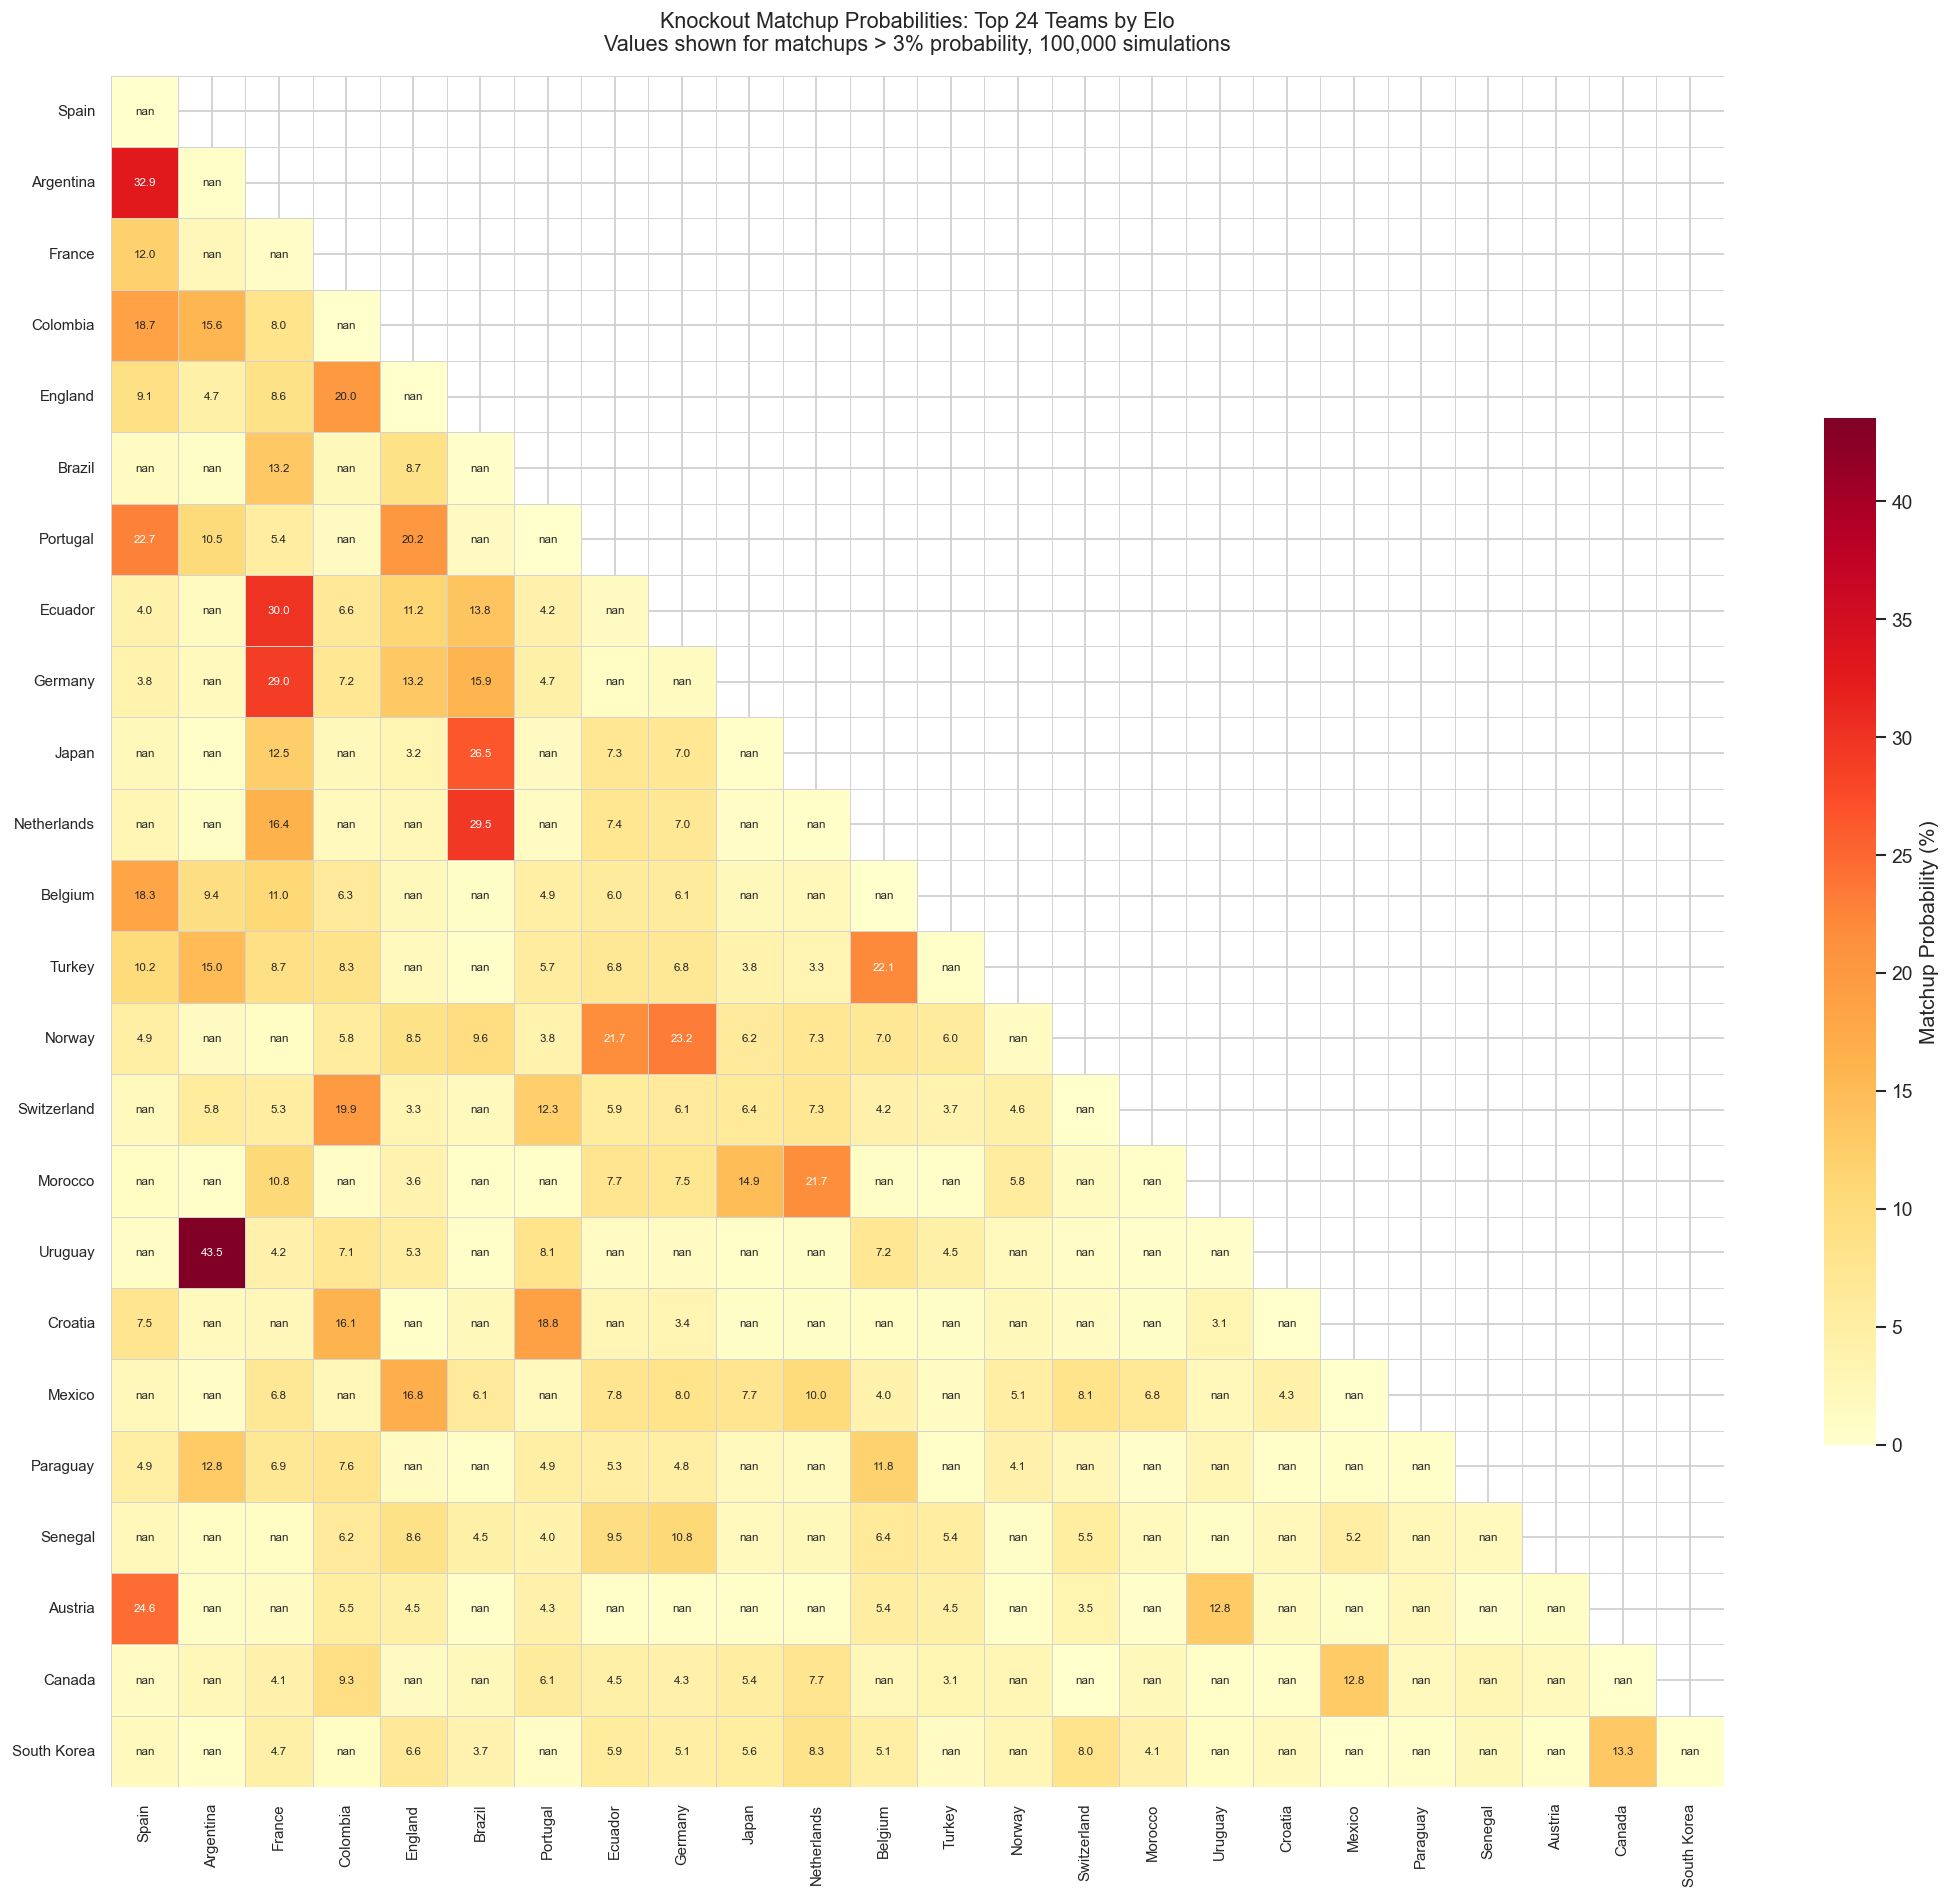

In [6]:
teams_top24 = team_order[:24]
mat24 = matchup_matrix.loc[teams_top24, teams_top24] * 100

fig, ax = plt.subplots(figsize=(18, 16))
mask24 = np.triu(np.ones_like(mat24, dtype=bool), k=1)

annot24 = mat24.copy()
annot24[annot24 < 3] = np.nan

sns.heatmap(mat24, mask=mask24, ax=ax, cmap='YlOrRd',
            vmin=0, vmax=mat24.values.max(),
            annot=annot24.round(1), fmt='.1f',
            annot_kws={'fontsize': 7},
            cbar_kws={'label': 'Matchup Probability (%)', 'shrink': 0.6},
            linewidths=0.5, linecolor='lightgray',
            xticklabels=True, yticklabels=True)

ax.set_title(f'Knockout Matchup Probabilities: Top 24 Teams by Elo\n'
             'Values shown for matchups > 3% probability, 100,000 simulations',
             fontsize=13, pad=15)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()

## B4. Team Matchup Profiles

Pick any team to see exactly who they are likely to face in knockout stages.


MATCHUP PROFILE: Argentina
Elo: 2190
R32 qualification: 98.0%

Group stage (100% guaranteed):
  vs Algeria                Elo 1885
  vs Austria                Elo 1929
  vs Jordan                 Elo 1766

Most likely knockout opponents:
  vs Uruguay                 43.5% █████████████████████
  vs Spain                   32.9% ████████████████
  vs Colombia                15.6% ███████
  vs Turkey                  15.0% ███████
  vs Paraguay                12.8% ██████
  vs United States           12.5% ██████
  vs Saudi Arabia            11.5% █████
  vs Australia               10.7% █████
  vs Portugal                10.5% █████
  vs Belgium                  9.4% ████
  vs Cape Verde               8.0% ████
  vs Iran                     7.2% ███
  vs Switzerland              5.8% ██
  vs Egypt                    5.4% ██
  vs England                  4.7% ██
  vs New Zealand              4.4% ██
  vs Canada                   2.6% █
  vs France                   2.5% █
  vs Croatia   

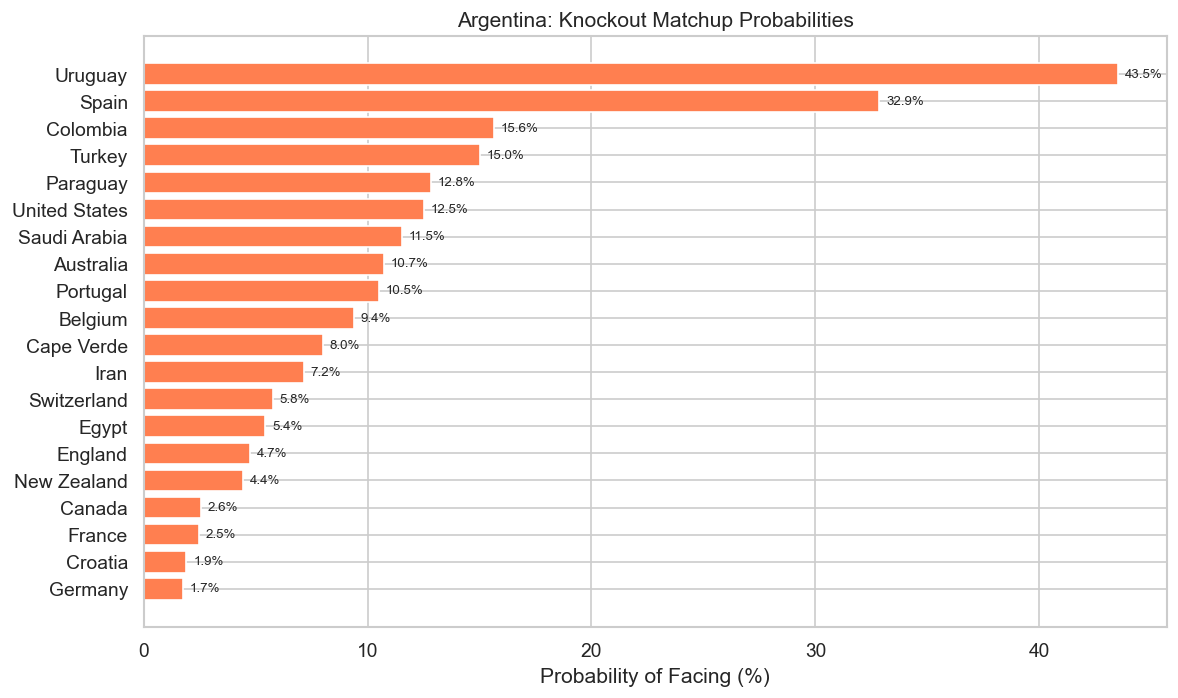

In [7]:
team = 'Argentina'  # Change this to explore any team

# Group stage opponents
grp_opponents = set()
for _, r in fixtures.iterrows():
    if r['Home_Team'] == team: grp_opponents.add(r['Away_Team'])
    if r['Away_Team'] == team: grp_opponents.add(r['Home_Team'])

# Knockout opponents (sorted by probability)
team_probs = matchup_matrix.loc[team].sort_values(ascending=False)
ko_probs = team_probs[~team_probs.index.isin(grp_opponents | {team})]

print(f'MATCHUP PROFILE: {team}')
print(f'Elo: {elo_data.get(team, 0):.0f}')
print(f'R32 qualification: {results.loc[team, "R32_Prob"]*100:.1f}%')
print()
print('Group stage (100% guaranteed):')
for opp in sorted(grp_opponents):
    e = elo_data.get(opp, 0)
    print(f'  vs {opp:<22} Elo {e:.0f}')
print()
print(f'Most likely knockout opponents:')
for opp, prob in ko_probs.head(20).items():
    e = elo_data.get(opp, 0)
    bar = '█' * int(prob * 100 / 2)
    print(f'  vs {opp:<22} {prob*100:5.1f}% {bar}')

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
top_ko = ko_probs.head(20)
bars = ax.barh(top_ko.index[::-1], top_ko.values[::-1] * 100, color='coral', edgecolor='white')
ax.set_title(f'{team}: Knockout Matchup Probabilities')
ax.set_xlabel('Probability of Facing (%)')
for bar, prob in zip(bars, top_ko.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{prob*100:.1f}%', va='center', fontsize=8)
plt.tight_layout()

## B5. Most Connected Teams in Knockout

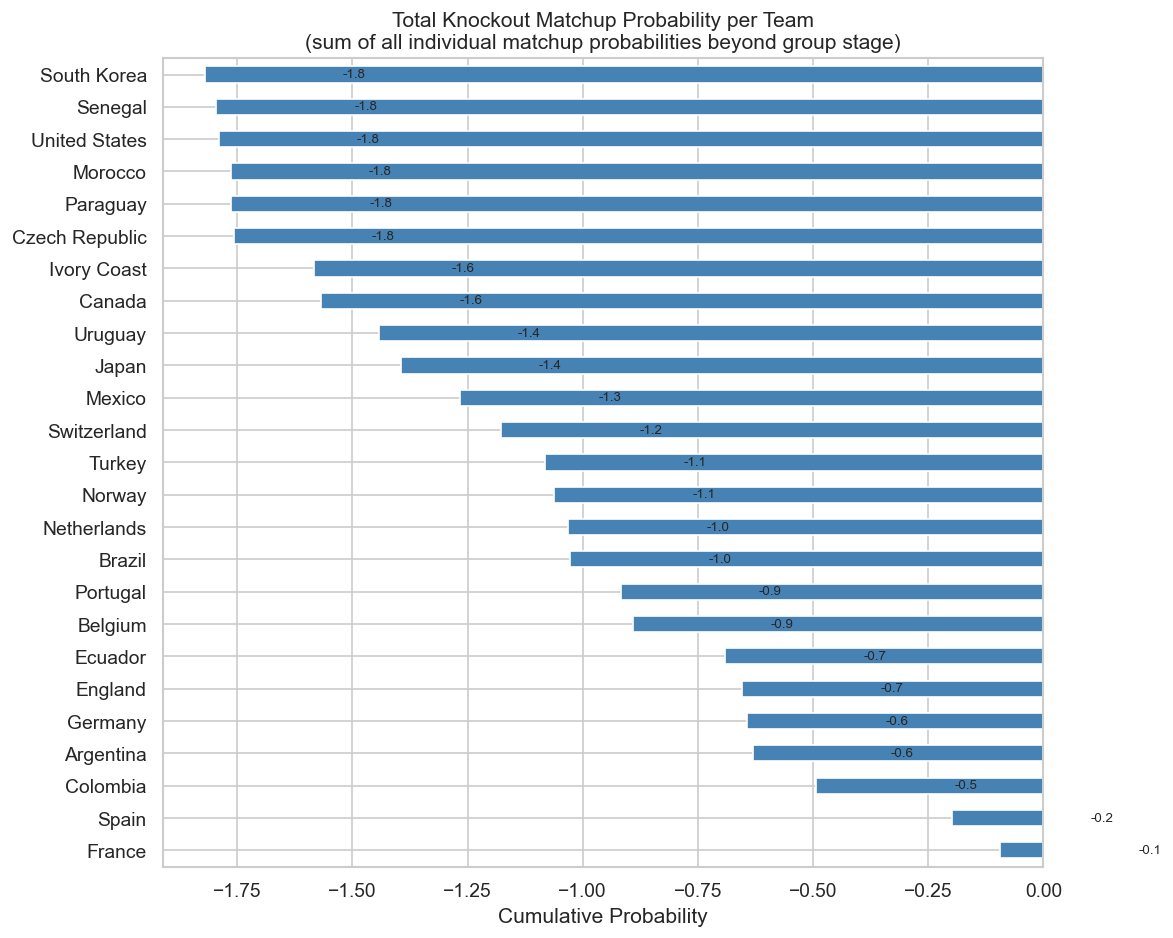

In [8]:
# Total probability of any knockout matchup per team
team_connections = {}
for team in matchup_matrix.index:
    total = matchup_matrix.loc[team].sum()
    # Remove group stage matches (exactly 3 per team at prob=1.0)
    team_connections[team] = total - 3

conn = pd.Series(team_connections).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
conn.head(25).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Knockout Matchup Probability per Team\n(sum of all individual matchup probabilities beyond group stage)')
ax.set_xlabel('Cumulative Probability')
for i, (team, prob) in enumerate(conn.head(25).items()):
    ax.text(prob + 0.3, i, f'{prob:.1f}', va='center', fontsize=8)
plt.tight_layout()

## B6. Bracket Structure (Fixed Paths)

In [9]:
print('2026 KNOCKOUT BRACKET')
print('=' * 80)
print()
print(f'{"R32":<32} {"R16":<16} {"QF":<16} {"SF":<16} {"Final"}')
print('-' * 88)

lines = [
    ('RU A vs RU B',             'M89 →', 'M97 →', 'M101 →'),
    ('W E vs 3rd A/B/C/D/F',     '',       '',       ''),
    ('W F vs RU C',              'M90 →', '',       'M105 →'),
    ('W C vs RU F',              '',       '',       ''),
    ('W I vs 3rd C/D/F/G/H',     'M91 →', 'M99 →', ''),
    ('RU E vs RU I',             '',       '',       'M106 →'),
    ('W A vs 3rd C/E/F/H/I',     'M92 →', 'M100 →', ''),
    ('W L vs 3rd E/H/I/J/K',     '',       '',       ''),
    ('W D vs 3rd B/E/F/I/J',     'M93 →', 'M98 →', 'M102 →'),
    ('W G vs 3rd A/E/H/I/J',     '',       '',       ''),
    ('RU K vs RU L',             'M94 →', '',       ''),
    ('W H vs RU J',              '',       '',       ''),
    ('W B vs 3rd E/F/G/I/J',     'M95 →', 'M100 →','M105 →'),
    ('W J vs RU H',              '',       '',       ''),
    ('W K vs 3rd D/E/I/J/L',     'M96 →', 'M102 →',''),
    ('RU D vs RU G',             '',       '',       'M106 →'),
]
for r32, r16, qf, sf in lines:
    print(f'{r32:<32} {r16:<16} {qf:<16} {sf:<16}')
print()
print('Top half of bracket feeds Final via M105; bottom half via M106.')
print('M105 winner vs M106 winner = WORLD CHAMPION')

2026 KNOCKOUT BRACKET

R32                              R16              QF               SF               Final
----------------------------------------------------------------------------------------
RU A vs RU B                     M89 →            M97 →            M101 →          
W E vs 3rd A/B/C/D/F                                                               
W F vs RU C                      M90 →                             M105 →          
W C vs RU F                                                                        
W I vs 3rd C/D/F/G/H             M91 →            M99 →                            
RU E vs RU I                                                       M106 →          
W A vs 3rd C/E/F/H/I             M92 →            M100 →                           
W L vs 3rd E/H/I/J/K                                                               
W D vs 3rd B/E/F/I/J             M93 →            M98 →            M102 →          
W G vs 3rd A/E/H/I/J                      

## B7. Summary

In [10]:
print('SUMMARY')
print('=' * 70)
print(f'Simulations: 100,000 full tournament runs')
print(f'Group stage: 72 guaranteed matchups across 12 groups')
print(f'Bracket: Correct 2026 structure with R32 third-place allocation')
print()
print('Group stage:')
print(f'  Matches: 72 (100% certain)')
print(f'  Teams advancing: 32 of 48')
print(f'  Group winners + runners-up: 24 teams')
print(f'  Best 8 third-place teams: 8 teams')
print()
print('Knockout stage (probabilistic):')
print(f'  R32: 16 matches (bracket-determined pairings)')
print(f'  R16 → QF → SF → Final: fixed progression paths')
print()
print('Top 5 most likely knockout matchups:')
for i, (_, r) in enumerate(matchup_list.nlargest(5, 'Probability').iterrows()):
    print(f'  {i+1}. {r["Team_A"]} vs {r["Team_B"]}: {r["Probability"]*100:.1f}%')
print()
print('Data files:')
print('  ../data/2026_matchup_probabilities.csv  (48x48 matrix)')
print('  ../data/2026_matchup_list.csv            (ranked knockout matchups)')
print('  ../data/2026_monte_carlo_results.csv     (stage advancement probabilities)')

SUMMARY
Simulations: 100,000 full tournament runs
Group stage: 72 guaranteed matchups across 12 groups
Bracket: Correct 2026 structure with R32 third-place allocation

Group stage:
  Matches: 72 (100% certain)
  Teams advancing: 32 of 48
  Group winners + runners-up: 24 teams
  Best 8 third-place teams: 8 teams

Knockout stage (probabilistic):
  R32: 16 matches (bracket-determined pairings)
  R16 → QF → SF → Final: fixed progression paths

Top 5 most likely knockout matchups:
  1. Argentina vs Uruguay: 43.5%
  2. Argentina vs Spain: 32.9%
  3. Ecuador vs France: 30.0%
  4. Brazil vs Netherlands: 29.5%
  5. France vs Germany: 29.0%

Data files:
  ../data/2026_matchup_probabilities.csv  (48x48 matrix)
  ../data/2026_matchup_list.csv            (ranked knockout matchups)
  ../data/2026_monte_carlo_results.csv     (stage advancement probabilities)
